# XGBoost Multiclass Classification

This notebook implements a complete machine learning pipeline for multiclass classification of coronary artery stenosis using XGBoost.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data
3. **Data Cleaning & Preprocessing**: Clean data, handle missing values, and prepare features
4. **Grid Search** (Optional): Optimize hyperparameters via cross-validation
5. **Model Training**: Train XGBoost classifier with SMOTE and feature selection
6. **Overfitting Check**: Compare training vs. test performance
7. **Model Evaluation**: Comprehensive evaluation metrics and confusion matrix
8. **ROC & PR Curves**: Visualize model performance across classes
9. **Feature Importance**: Identify most important features


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **xgboost**: Gradient boosting classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    recall_score, precision_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse
import shap



/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Converts European number format (commas to dots)
- Automatically converts numeric columns to appropriate data types
- Separates features (X) from the target variable (y = OUTCOME_3Kat_KHK)
- The target has 3 classes: 0 (No Stenosis), 1 (Non-significant stenosis), 2 (Significant Stenosis)


In [ ]:
data = pd.read_csv(
    '../data/T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

data = data.replace(",", ".", regex=True)

for col in data.columns:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):
        data[col] = temp

data = data.apply(pd.to_numeric, errors='ignore')

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]



/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_64354/1045311303.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_64354/1045311303.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


## 3. Data Cleaning & Preprocessing

This cell performs comprehensive data cleaning and preprocessing:

**Data Cleaning:**
- Removes dependent variables (e.g., LDL, HDL, cholesterol components) that are directly derived from other features
- Identifies categorical and numerical features
- Removes highly correlated features (correlation > 0.95) to reduce redundancy and prevent multicollinearity

**Train/Test Split:**
- Splits data into 75% training and 25% test set (as specified in the paper)
- Uses stratified split to maintain class distribution in both sets

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: kNN Imputation (k=5) + MinMax Scaling (normalizes to [0,1])
- Falls back to IterativeImputer or Median imputation if kNN fails
- Fits preprocessor on training data and transforms both training and test sets
- Converts sparse matrices to dense arrays for compatibility with XGBoost


In [ ]:
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

manual_categorical = [
    "geschlecht", "currsmo0", "diabetes_ADA_final_0",
    "ANY_OPE", "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

for col in manual_categorical:
    if col in data.columns:
        data[col] = data[col].astype(str)

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_preprocessor = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

try:
    num_preprocessor = SklearnPipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ])
    print("Using KNNImputer + MinMaxScaler")
except:
    try:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", IterativeImputer(random_state=42, max_iter=10)),
            ("scaler", MinMaxScaler())
        ])
        print("Using IterativeImputer + MinMaxScaler (fallback)")
    except:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ])
        print("Using Median + MinMaxScaler (fallback)")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features)
    ],
    remainder="passthrough"
)

X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed = preprocessor.transform(X_test)

if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nPreprocessing complete: {X_train_transformed.shape[1]} features after transformation")



Categorical features: 7
Numerical features: 634
Removing 428 highly correlated features
After cleaning - Numerical: 206, Categorical: 7
Using KNNImputer + MinMaxScaler

Preprocessing complete: 224 features after transformation


## 4. Grid Search (Optional - Run Once to Optimize Hyperparameters)

This cell performs hyperparameter optimization using Grid Search with 5-fold stratified cross-validation. It tests multiple combinations of hyperparameters to find the optimal configuration.

**Process:**
- Builds a pipeline with feature selection, SMOTE, and XGBoost classifier
- Tests different values for: number of features (k), number of trees, learning rate, tree depth, regularization parameters, and sampling rates
- Uses balanced accuracy as the scoring metric (important for imbalanced classes)
- Saves the best parameters to be used in the model training cell

**Note:** This cell can take a long time to run (testing thousands of parameter combinations). Run it once to optimize, then use the results in the training cell. You can skip this cell and use default optimized parameters instead.


In [ ]:

print("=" * 80)
print("GRID SEARCH - Hyperparameter Optimization")
print("=" * 80)
print("\nWARNING: This may take a while! Run this cell only when you want to re-optimize.")
print("    After completion, best parameters will be saved for the training cell.\n")

pipeline_base = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=50)),
    ("smote", SMOTE(random_state=42, k_neighbors=3, sampling_strategy='auto')),
    ("classifier", XGBClassifier(
        tree_method="hist",
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
        objective="multi:softprob",
        num_class=3
    )),
])

param_grid = {
    'feature_selection__k': [40, 50, 60, 75],
    'classifier__n_estimators': [100, 150, 200],
    'classifier__learning_rate': [0.01, 0.02, 0.03],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_child_weight': [3, 5, 7],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
    'classifier__reg_lambda': [1.0, 2.0, 3.0],
    'classifier__reg_alpha': [0.5, 1.0, 1.5]
}

print(f"\nStarting Grid Search with 5-fold CV (as in paper)...")
print(f"   Parameter combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
print(f"   This may take a while...\n")

grid_search = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_transformed, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nGrid Search completed!")
print(f"   Best CV Score (Balanced Accuracy): {best_score:.4f}")
print(f"   Best Parameters saved for training cell:")
for param, value in best_params.items():
    print(f"     {param}: {value}")

print(f"\nYou can now run the training cell (next cell) which will use these parameters.")
print(f"   No need to run Grid Search again unless you want to re-optimize.")



GRID SEARCH - Hyperparameter Optimization

    After completion, best parameters will be saved for the training cell.


Starting Grid Search with 5-fold CV (as in paper)...
   Parameter combinations to test: 26244
   This may take a while...

Fitting 5 folds for each of 26244 candidates, totalling 131220 fits


[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=100, classifier__reg_alpha=0.5, classifier__reg_lambda=1.0, classifier__subsample=0.7, feature_selection__k=40; total time=   1.1s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=100, classifier__reg_alpha=0.5, classifier__reg_lambda=1.0, classifier__subsample=0.7, feature_selection__k=40; total time=   1.1s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=100, classifier__reg_alpha=0.5, classifier__reg_lambda=1.0, classifier__subsample=0.7, feature_selection__k=40; total time=   1.1s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, clas

KeyboardInterrupt: 

## 5. Model Training

This cell trains the final XGBoost model using the optimized hyperparameters from Grid Search (if available) or default optimized parameters.

**Pipeline Components:**
1. **Feature Selection**: SelectKBest with mutual information (selects k most informative features)
2. **SMOTE**: Synthetic oversampling to balance classes (k_neighbors=3 to reduce overfitting)
3. **XGBoost Classifier**: Gradient boosting with optimized hyperparameters

**Hyperparameters:**
- If Grid Search was run: Uses best parameters from Grid Search
- Otherwise: Uses optimized default parameters (n_estimators=200, learning_rate=0.03, max_depth=4, etc.)

The model is trained on the preprocessed training data, and predictions are made on the test set. Feature selection results are displayed showing how many features were selected.


In [ ]:
np.random.seed(42)

if 'best_params' in globals() and best_params is not None:
    print("=" * 80)
    print("MODEL TRAINING - Using Optimized Hyperparameters from Grid Search")
    print("=" * 80)
    print(f"\nUsing best parameters from Grid Search:")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    use_grid_search_params = True
    
    K_FEATURES = best_params['feature_selection__k']
    XGB_PARAMS = {
        'n_estimators': best_params['classifier__n_estimators'],
        'learning_rate': best_params['classifier__learning_rate'],
        'max_depth': best_params['classifier__max_depth'],
        'min_child_weight': best_params['classifier__min_child_weight'],
        'subsample': best_params['classifier__subsample'],
        'colsample_bytree': best_params['classifier__colsample_bytree'],
        'reg_lambda': best_params['classifier__reg_lambda'],
        'reg_alpha': best_params['classifier__reg_alpha'],
        'tree_method': 'hist',
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'objective': 'multi:softprob',
        'num_class': 3
    }
    SMOTE_K_NEIGHBORS = 3
else:
    print("=" * 80)
    print("MODEL TRAINING - Using Optimized Default Parameters")
    print("=" * 80)
    print(f"\nUsing optimized default parameters (from previous Grid Search results).")
    print(f"   Run the Grid Search cell if you want to re-optimize.")
    use_grid_search_params = False
    
    K_FEATURES = 100
    SMOTE_K_NEIGHBORS = 3
    XGB_PARAMS = {
        'n_estimators': 200,
        'learning_rate': 0.03,
        'max_depth': 4,
        'min_child_weight': 3,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_lambda': 2.0,
        'reg_alpha': 1.0,
        'tree_method': 'hist',
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'objective': 'multi:softprob',
        'num_class': 3
    }
    print(f"   Using optimized default parameters (from Grid Search results):")

print(f"\nMethods:")
print(f"  1. kNN Imputation + MinMax Scaling")
print(f"  2. 75:25 Train/Test Split")
print(f"  3. SMOTE Oversampling (k_neighbors={SMOTE_K_NEIGHBORS})")
print(f"  4. Feature Selection (k={K_FEATURES})")
print(f"  5. XGBoost with {'optimized' if use_grid_search_params else 'default'} hyperparameters")

pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=K_FEATURES)),
    ("smote", SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')),
    ("classifier", XGBClassifier(**XGB_PARAMS))
])

print(f"\nTraining model...")
pipeline.fit(X_train_transformed, y_train)

feature_selector = pipeline.named_steps['feature_selection']
selected_features_mask = feature_selector.get_support()
X_train_selected = X_train_transformed[:, selected_features_mask]
X_test_selected = X_test_transformed[:, selected_features_mask]

print(f"\nFeature Selection:")
print(f"   Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

y_pred = pipeline.predict(X_test_transformed)
y_proba = pipeline.predict_proba(X_test_transformed)

print(f"\nModel training completed!")

if use_grid_search_params and 'best_score' in globals():
    print(f"\nGrid Search CV Score: {best_score:.4f}")



MODEL TRAINING - Using Optimized Default Parameters

Using optimized default parameters (from previous Grid Search results).
   Run the Grid Search cell if you want to re-optimize.
   Using optimized default parameters (from Grid Search results):

Methods:
  1. kNN Imputation + MinMax Scaling
  2. 75:25 Train/Test Split
  3. SMOTE Oversampling (k_neighbors=3)
  4. Feature Selection (k=100)
  5. XGBoost with default hyperparameters

Training model...

Feature Selection:
   Selected 100 features out of 224

Model training completed!


## 6. Overfitting Check

This cell compares model performance on training vs. test data to detect overfitting. A well-generalizing model should have similar performance on both sets.

**Metrics Compared:**
- **Recall for Class 2** (Significant Stenosis): Most important metric for clinical application
- **Balanced Accuracy**: Average recall across all classes (accounts for class imbalance)
- **Regular Accuracy**: Overall classification accuracy

**Interpretation:**
- Small gap (< 0.10): Good generalization
- Moderate gap (0.10-0.15): Some overfitting, acceptable
- Large gap (> 0.15): Significant overfitting, model may not generalize well to new data

The cell automatically flags warnings if large gaps are detected.


In [ ]:
y_pred_train = pipeline.predict(X_train_transformed)
y_pred_test = y_pred

train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None, zero_division=0)[0]
test_recall_class2 = recall_score(y_test, y_pred_test, labels=[2], average=None, zero_division=0)[0]
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK")
print("=" * 80)
print(f"\nRecall (Significant Stenosis - Class 2):")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print(f"\nBalanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print(f"\nRegular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")

gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("\nWARNING: Large gap detected - model may be overfitting!")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("\nCAUTION: Moderate gap detected")
else:
    print("\nModel shows good generalization")



OVERFITTING CHECK

Recall (Significant Stenosis - Class 2):
  Training: 0.8874
  Test:     0.7082
  Gap:      0.1792

Balanced Accuracy:
  Training: 0.8675
  Test:     0.5053
  Gap:      0.3622

Regular Accuracy:
  Training: 0.8678
  Test:     0.5640
  Gap:      0.3038



## 7. Model Evaluation

This cell provides a comprehensive evaluation of the model's performance on the test set.

**Metrics Reported:**
- **Overall Accuracy**: Percentage of correctly classified samples
- **Balanced Accuracy**: Average recall across all classes (better for imbalanced data)
- **Classification Report**: Per-class precision, recall, F1-score, and support
- **Confusion Matrix**: Visual representation of predictions vs. actual labels

The confusion matrix shows how many samples from each class were correctly/incorrectly classified, helping identify which classes are most confused with each other.


MODEL EVALUATION REPORT

Overall Accuracy: 0.5640 (56.40%)
Balanced Accuracy: 0.5053 (50.53%)

CLASSIFICATION REPORT
                               precision    recall  f1-score   support

             No Stenosis (X0)     0.4017    0.5165    0.4519        91
Non-significant stenosis (X1)     0.3966    0.2911    0.3358       158
    Significant Stenosis (X2)     0.6754    0.7082    0.6914       329

                     accuracy                         0.5640       578
                    macro avg     0.4912    0.5053    0.4930       578
                 weighted avg     0.5561    0.5640    0.5565       578


CONFUSION MATRIX


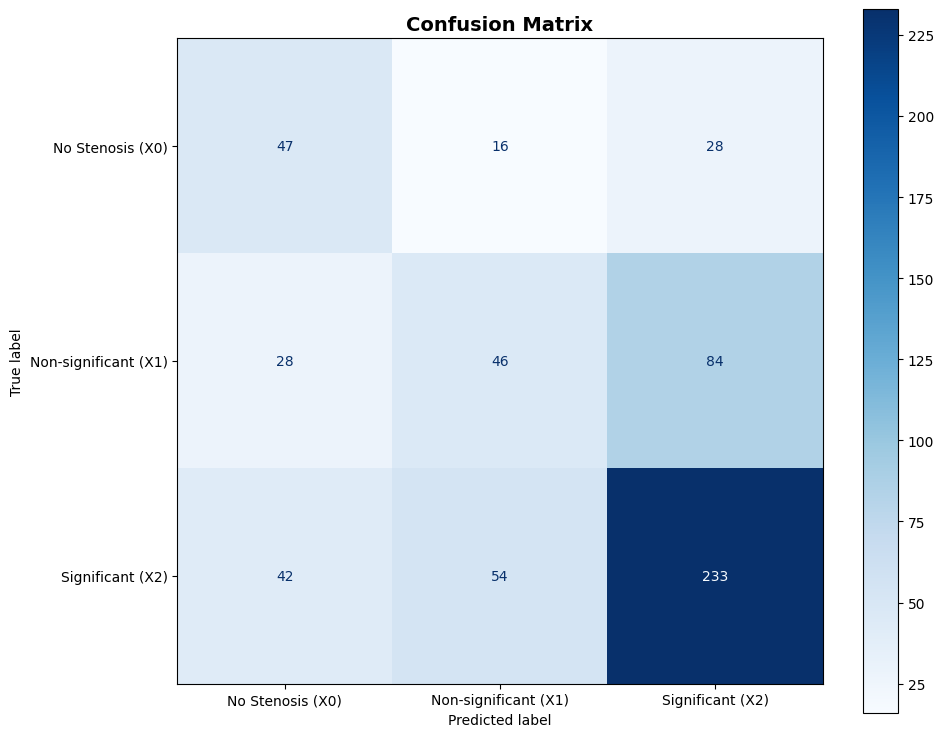

In [ ]:
print("=" * 80)
print("MODEL EVALUATION REPORT")
print("=" * 80)

overall_accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(
    y_test, y_pred,
    target_names=["No Stenosis (X0)", "Non-significant stenosis (X1)", "Significant Stenosis (X2)"],
    digits=4
))

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2],
    display_labels=["No Stenosis (X0)", "Non-significant (X1)", "Significant (X2)"],
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## 8. ROC & PR Curves

This cell visualizes model performance using Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves for each class.

**ROC Curves:**
- Shows the trade-off between True Positive Rate (sensitivity) and False Positive Rate (1 - specificity)
- AUC (Area Under Curve) closer to 1.0 indicates better performance
- Useful when classes are relatively balanced

**Precision-Recall Curves:**
- Shows the trade-off between precision and recall
- AP (Average Precision) closer to 1.0 indicates better performance
- More informative than ROC for imbalanced datasets

Both curves are plotted for all three classes (No Stenosis, Non-significant, Significant Stenosis) to assess per-class performance.


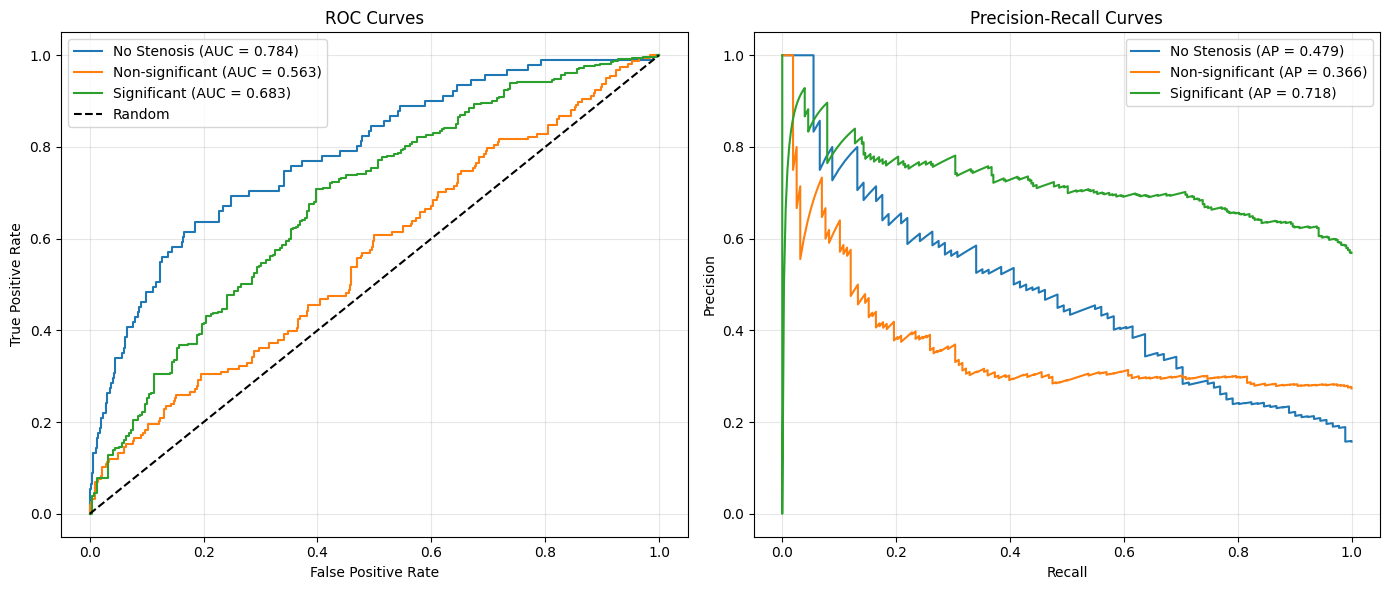

In [ ]:
classes = pipeline.named_steps['classifier'].classes_
Y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = {0: "No Stenosis", 1: "Non-significant", 2: "Significant"}.get(cls, f"Class {cls}")
    ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    pr_auc = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    class_name = {0: "No Stenosis", 1: "Non-significant", 2: "Significant"}.get(cls, f"Class {cls}")
    ax.plot(recall, precision, label=f'{class_name} (AP = {pr_auc:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 9. Feature Importance

This cell identifies and visualizes the most important features used by the XGBoost model.

**Process:**
- Extracts feature names from the preprocessing pipeline
- Maps selected features (after feature selection) to their original names
- Uses XGBoost's built-in feature importance (based on F-score/weight)
- Displays the top 10 most important features

**Interpretation:**
- Features with higher F-scores contribute more to the model's predictions
- This helps understand which patient characteristics are most predictive of stenosis severity
- Useful for clinical interpretation and feature engineering insights


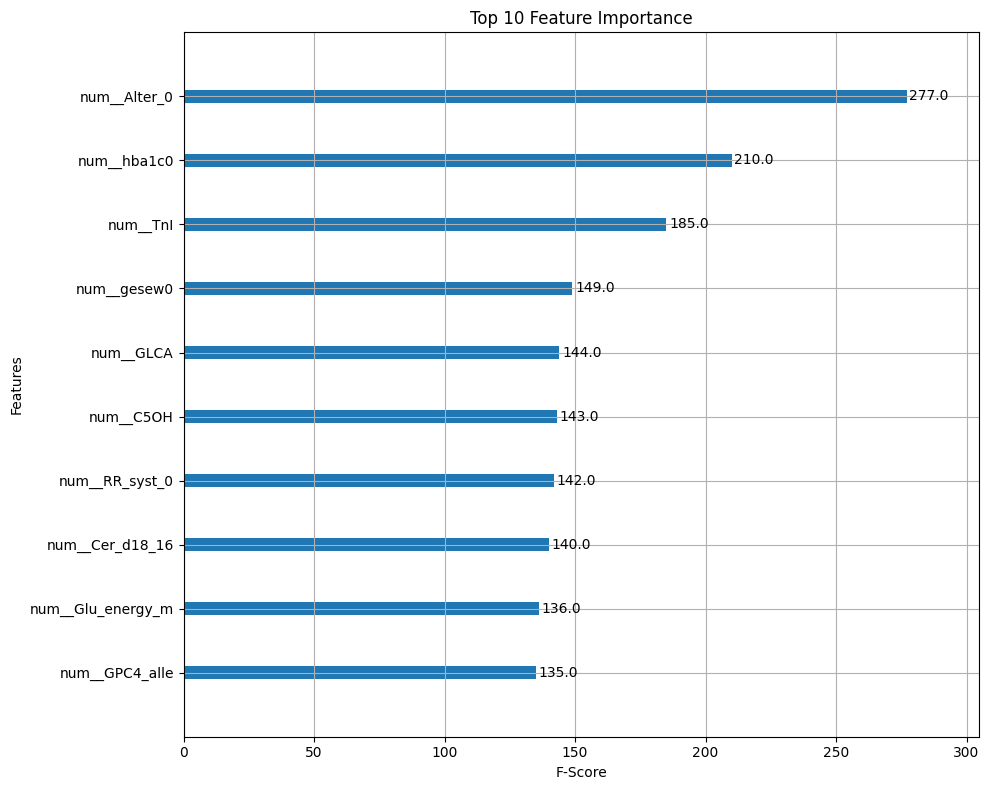

In [ ]:
feature_names = preprocessor.get_feature_names_out()
selected_indices = feature_selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

xgb_model = pipeline.named_steps['classifier']
booster = xgb_model.get_booster()
booster.feature_names = selected_feature_names

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(booster, ax=ax, importance_type='weight', xlabel='F-Score', max_num_features=10)
ax.set_title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()



## 10. SHAP Analysis

This cell performs SHAP (SHapley Additive exPlanations) analysis to explain individual predictions and understand feature contributions.

**What is SHAP?**
- SHAP values explain how each feature contributes to a specific prediction
- Based on game theory (Shapley values) - fairly distributes contribution among features
- Shows both the direction (positive/negative) and magnitude of each feature's impact

**Process:**
1. Creates a TreeExplainer (optimized for tree-based models like XGBoost)
2. Computes SHAP values for all test samples across all three classes
3. Visualizes results using beeswarm plots (one for each class)

**Visualization:**
- Each point represents one sample's SHAP value for a feature
- Color indicates the feature value (blue = low, yellow = high)
- Horizontal position shows SHAP value (left = decreases prediction, right = increases)
- Top 6 most important features per class are displayed

**Interpretation:**
- Features with points further from zero have larger impact
- Positive SHAP values push prediction toward that class
- Negative SHAP values push prediction away from that class
- Helps understand which patient characteristics drive each classification decision

**Note:** This cell requires the SHAP library. If not installed, it will show a warning and skip the analysis. Install with: `pip install shap`

SHAP values computed: shape (578, 100, 3)
  - Samples: 578
  - Features: 100
  - Classes: 3


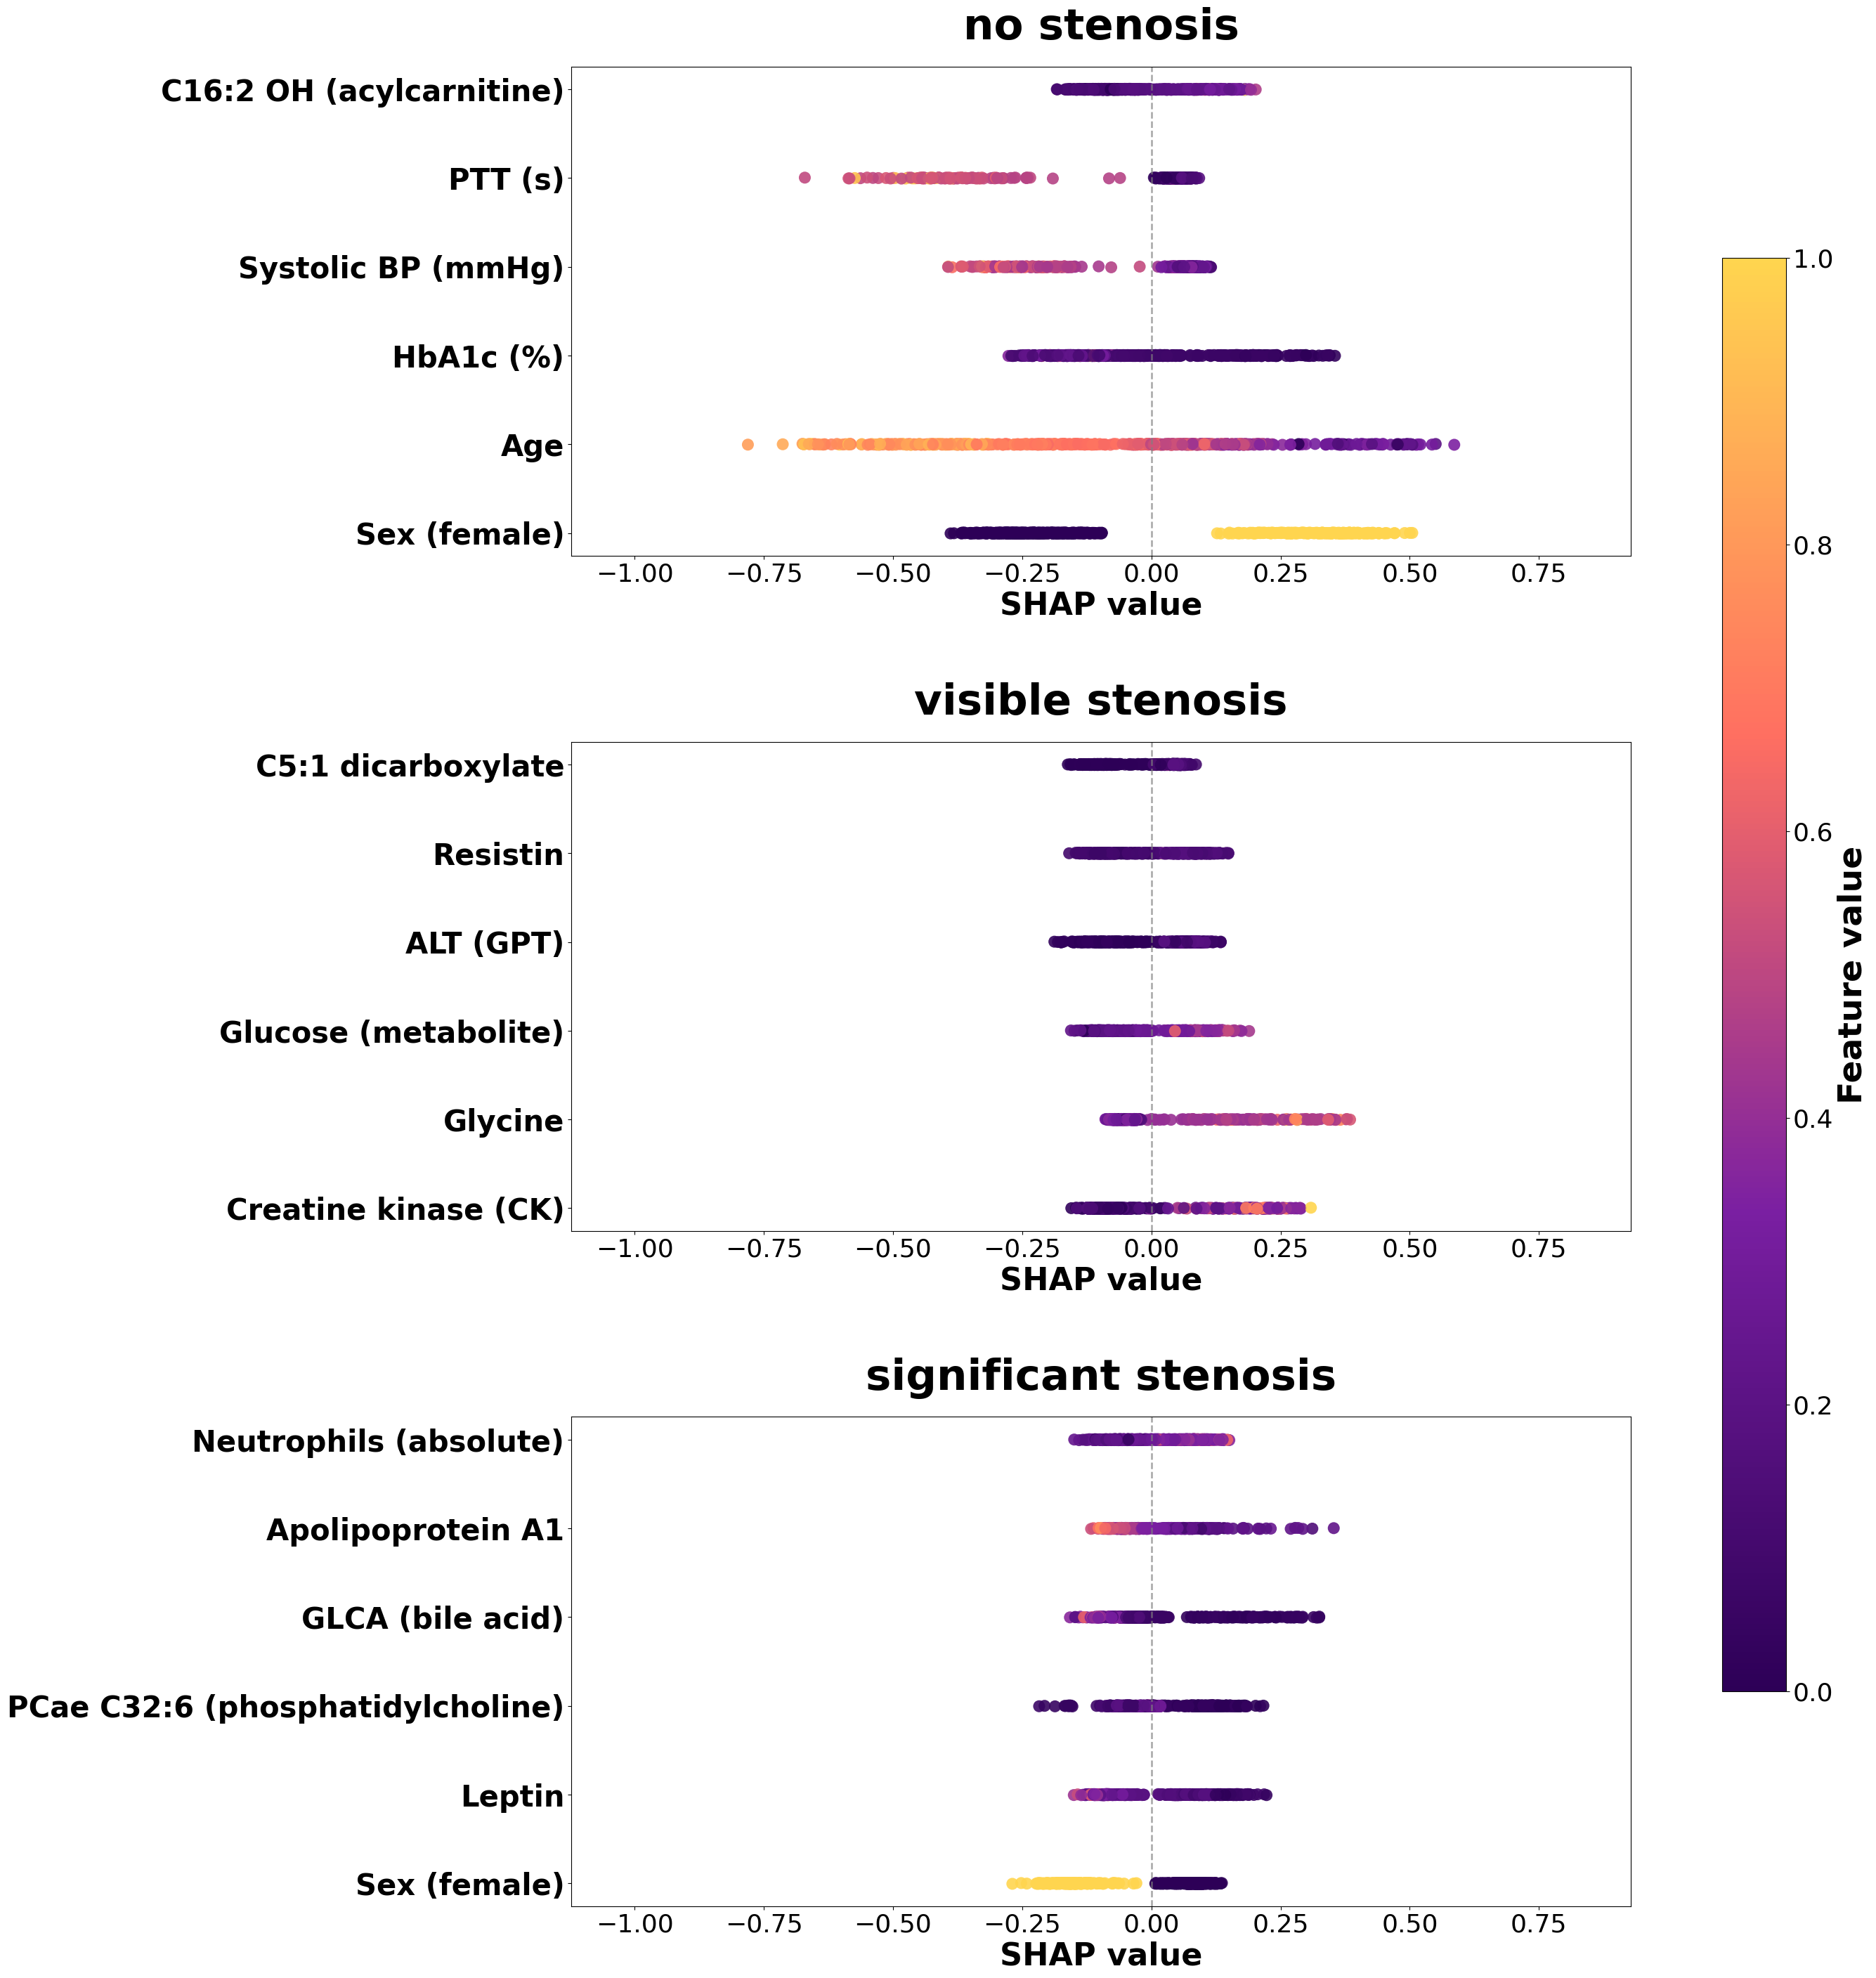

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pretty_names = {
    "cat__geschlecht_0": "Sex (female)",
    "cat__geschlecht_1": "Sex (male)",

    "num__Alter_0": "Age",
    "num__RR_syst_0": "Systolic BP (mmHg)",
    "num__hba1c0": "HbA1c (%)",
    "num__ptt0": "PTT (s)",

    "num__TnI": "Troponin I",
    "num__HGmax": "Max Heart Rate",

    "num__Leptin_n": "Leptin",
    "num__Resistin": "Resistin",
    "num__Gly": "Glycine",
    "num__Glu_energy_m": "Glucose (metabolite)",
    "num__GLCA": "GLCA (bile acid)",

    "num__apo_A1_gesamt_0": "Apolipoprotein A1",
    "num__Lp_a_0": "Lipoprotein(a)",

    "num__NEUT_ABS_gesamt": "Neutrophils (absolute)",
    "num__gesew0": "ESR (sedimentation rate)",

    "num__gpt0": "ALT (GPT)",
    "num__ldh0": "LDH",
    "num__cpk0": "Creatine kinase (CK)",

    "num__C162OH": "C16:2 OH (acylcarnitine)",
    "num__C51DC": "C5:1 dicarboxylate",
    "num__C5OH": "C5-OH acylcarnitine",
    "num__PCaeC326l": "PCae C32:6 (phosphatidylcholine)",
    "num__PSaaC422l": "PSaa C42:2 (phosphatidylserine)",

    "num__Klotho": "Klotho",
    "num__Galektin3": "Galectin-3",
}


def nice(n):
    return pretty_names.get(n, n)

titles = ["no stenosis", "visible stenosis", "significant stenosis"]

import shap

xgb_model = pipeline.named_steps['classifier']

feature_selector = pipeline.named_steps['feature_selection']
selected_features_mask = feature_selector.get_support()
X_test_selected = X_test_transformed[:, selected_features_mask]

feature_names = preprocessor.get_feature_names_out()
selected_indices = feature_selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_selected)

shap_values_array = np.array(shap_values)

print(f"SHAP values computed: shape {shap_values_array.shape}")
print(f"  - Samples: {shap_values_array.shape[0]}")
print(f"  - Features: {shap_values_array.shape[1]}")
print(f"  - Classes: {shap_values_array.shape[2]}")

TOP_N = 6

cmap = LinearSegmentedColormap.from_list(
    "styleB",
    ["#2d0057", "#7a1fa2", "#ff6f61", "#ffd54f"]
)

def plot_beeswarm(ax, shap_vals, feature_vals, feat_names,
                  vertical_spacing=3.6, jitter_scale=0.045):

    importance = np.mean(np.abs(shap_vals), axis=0)
    order = np.argsort(importance)[-TOP_N:][::-1]

    shap_vals = shap_vals[:, order]
    feature_vals = feature_vals[:, order]
    feat_names = [nice(feat_names[i]) for i in order]

    y_positions = np.arange(TOP_N) * vertical_spacing

    for y, (sv, fv) in zip(y_positions, zip(shap_vals.T, feature_vals.T)):
        norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-12)
        colors = cmap(norm)
        jitter = (np.random.rand(len(sv)) - 0.5) * jitter_scale

        ax.scatter(
            sv,
            y + jitter,
            c=colors,
            s=150,         
            alpha=0.90,
            edgecolor="none"
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(feat_names, fontsize=30, fontweight="bold")

    ax.axvline(0, color="gray", linestyle="--", linewidth=1.8, alpha=0.7)
    ax.tick_params(axis="x", labelsize=26)
    ax.set_xlabel("SHAP value", fontsize=32, fontweight="bold")


fig = plt.figure(figsize=(26, 34))

gs = fig.add_gridspec(3, 1, hspace=0.38, left=0.20, right=0.78)

axes = [fig.add_subplot(gs[i, 0]) for i in range(3)]

global_min = np.min(shap_values_array)
global_max = np.max(shap_values_array)
xpad = (global_max - global_min) * 0.25

for i, ax in enumerate(axes):

    plot_beeswarm(
        ax,
        shap_values_array[:, :, i],
        X_test_selected,
        selected_feature_names,
        vertical_spacing=3.8,
        jitter_scale=0.045
    )

    ax.set_title(titles[i], fontsize=44, fontweight="bold", pad=28)
    ax.set_xlim(global_min - xpad, global_max + xpad)


cbar_ax = fig.add_axes([0.83, 0.20, 0.035, 0.60])

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Feature value", fontsize=34, fontweight="bold")
cbar.ax.tick_params(labelsize=26)

plt.show()
